# HW08-09: PyTorch MLP - регуляризация и оптимизация обучения

## Вариант B: EMNIST(split="balanced")

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import pandas as pd
import json
from datetime import datetime

# Фиксируем seed для воспроизводимости
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Определяем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cpu


In [6]:
# Данные и DataLoader

# Трансформации
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Загрузка датасета EMNIST balanced
train_full = torchvision.datasets.EMNIST(
    root="./data", 
    split="balanced", 
    train=True, 
    download=True, 
    transform=transform
)

test_ds = torchvision.datasets.EMNIST(
    root="./data", 
    split="balanced", 
    train=False, 
    download=True, 
    transform=transform
)

print(f"Train size: {len(train_full)}")
print(f"Test size: {len(test_ds)}")
print(f"Classes: {len(train_full.classes)} ({train_full.classes})")

100.0%


Train size: 112800
Test size: 18800
Classes: 47 (['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't'])


In [7]:
# Разбиение train/val
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

# Создание DataLoader
BATCH_SIZE = 128
NUM_WORKERS = 0 if os.name == "nt" else 2

train_loader = DataLoader(
    train_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS, 
    pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS, 
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_ds, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS, 
    pin_memory=(device.type == "cuda")
)

# Sanity-check
x_batch, y_batch = next(iter(train_loader))
print(f"x_batch shape: {x_batch.shape}")
print(f"y_batch shape: {y_batch.shape}")
print(f"x_batch range: [{x_batch.min():.3f}, {x_batch.max():.3f}]")

x_batch shape: torch.Size([128, 1, 28, 28])
y_batch shape: torch.Size([128])
x_batch range: [-1.000, 1.000]


In [8]:
# Модель MLP
class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int = 28 * 28,
        hidden_dims: tuple = (256, 128),
        num_classes: int = 47,  # EMNIST balanced имеет 47 классов
        activation: str = "relu",
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ):
        super().__init__()

        act = activation.lower()
        if act == "relu":
            act_layer = nn.ReLU
        elif act == "tanh":
            act_layer = nn.Tanh
        elif act == "gelu":
            act_layer = nn.GELU
        else:
            raise ValueError(f"Unknown activation: {activation}")

        layers = [nn.Flatten()]

        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_layer())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h

        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Проверка модели
model = MLP(hidden_dims=(256, 128), dropout_p=0.2, use_batchnorm=True).to(device)
with torch.no_grad():
    out = model(x_batch.to(device))
print(f"Model output shape: {out.shape}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Model output shape: torch.Size([128, 47])
Number of parameters: 240687


In [9]:
# Функции для обучения и оценки
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [ ]:
# EarlyStopping
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False

        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model: nn.Module) -> None:
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [11]:
# Функция для обучения модели
def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs: int = 20,
    early_stopping=None,
    verbose: bool = True,
):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        if verbose:
            print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={va_loss:.4f}, acc={va_acc:.4f}"
            )

        if early_stopping is not None:
            should_stop = early_stopping.step(va_acc, model)
            if should_stop:
                if verbose:
                    print(
                        f"EarlyStopping: остановка на эпохе {epoch}. "
                        f"Лучший val_acc={early_stopping.best_score:.4f}"
                    )
                early_stopping.restore_best(model)
                break

    return history

In [12]:
# Визуализация истории обучения
def plot_history(history: dict, title: str = "") -> None:
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title((title + " (loss)") if title else "loss")
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title((title + " (accuracy)") if title else "accuracy")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Часть A (S08): регуляризация и переобучение

epoch 01/20 | train loss=1.3021, acc=0.6279 | val loss=0.8917, acc=0.7304
epoch 02/20 | train loss=0.7292, acc=0.7715 | val loss=0.6862, acc=0.7839
epoch 03/20 | train loss=0.5988, acc=0.8054 | val loss=0.6037, acc=0.8057
epoch 04/20 | train loss=0.5318, acc=0.8233 | val loss=0.5627, acc=0.8210
epoch 05/20 | train loss=0.4909, acc=0.8353 | val loss=0.5342, acc=0.8255
epoch 06/20 | train loss=0.4588, acc=0.8433 | val loss=0.5304, acc=0.8261
epoch 07/20 | train loss=0.4367, acc=0.8486 | val loss=0.5222, acc=0.8283
epoch 08/20 | train loss=0.4134, acc=0.8548 | val loss=0.5105, acc=0.8331
epoch 09/20 | train loss=0.3942, acc=0.8590 | val loss=0.5168, acc=0.8336
epoch 10/20 | train loss=0.3800, acc=0.8634 | val loss=0.5168, acc=0.8300
epoch 11/20 | train loss=0.3642, acc=0.8682 | val loss=0.5134, acc=0.8397
epoch 12/20 | train loss=0.3550, acc=0.8694 | val loss=0.5200, acc=0.8340
epoch 13/20 | train loss=0.3411, acc=0.8742 | val loss=0.5253, acc=0.8385
epoch 14/20 | train loss=0.3324, acc=0

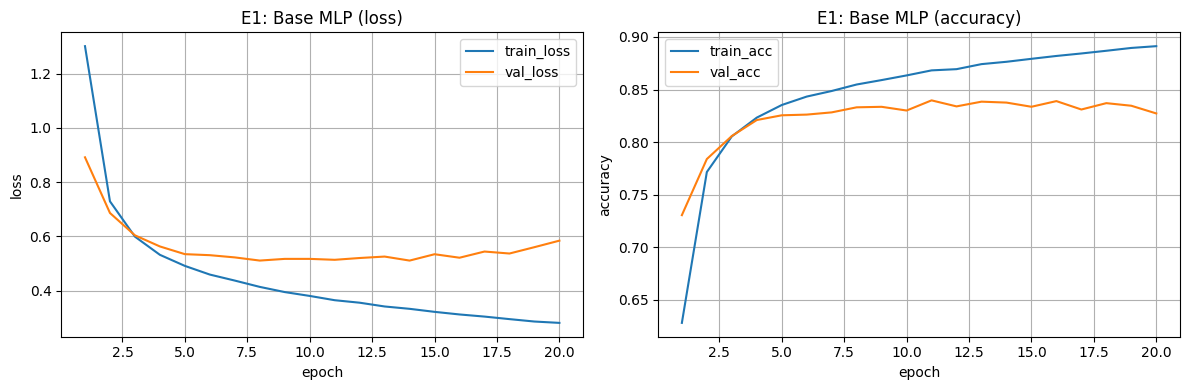

E1 Test: loss=0.6043, acc=0.8242


In [13]:
# Эксперимент E1 (base): MLP без Dropout и BatchNorm
set_seed(42)
model_e1 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e1.parameters(), lr=1e-3)

history_e1 = fit(
    model_e1, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_e1, title="E1: Base MLP")

# Оценка на тесте
test_loss_e1, test_acc_e1 = evaluate(model_e1, test_loader, criterion, device)
print(f"E1 Test: loss={test_loss_e1:.4f}, acc={test_acc_e1:.4f}")

epoch 01/20 | train loss=1.6769, acc=0.5184 | val loss=0.9506, acc=0.7156
epoch 02/20 | train loss=1.0811, acc=0.6689 | val loss=0.7619, acc=0.7640
epoch 03/20 | train loss=0.9545, acc=0.7041 | val loss=0.6839, acc=0.7838
epoch 04/20 | train loss=0.8952, acc=0.7201 | val loss=0.6583, acc=0.7930
epoch 05/20 | train loss=0.8514, acc=0.7321 | val loss=0.6201, acc=0.8023
epoch 06/20 | train loss=0.8135, acc=0.7405 | val loss=0.5971, acc=0.8070
epoch 07/20 | train loss=0.7991, acc=0.7445 | val loss=0.5900, acc=0.8069
epoch 08/20 | train loss=0.7773, acc=0.7489 | val loss=0.5681, acc=0.8119
epoch 09/20 | train loss=0.7625, acc=0.7526 | val loss=0.5592, acc=0.8172
epoch 10/20 | train loss=0.7493, acc=0.7576 | val loss=0.5508, acc=0.8189
epoch 11/20 | train loss=0.7373, acc=0.7620 | val loss=0.5405, acc=0.8204
epoch 12/20 | train loss=0.7270, acc=0.7626 | val loss=0.5430, acc=0.8199
epoch 13/20 | train loss=0.7190, acc=0.7648 | val loss=0.5350, acc=0.8222
epoch 14/20 | train loss=0.7164, acc=0

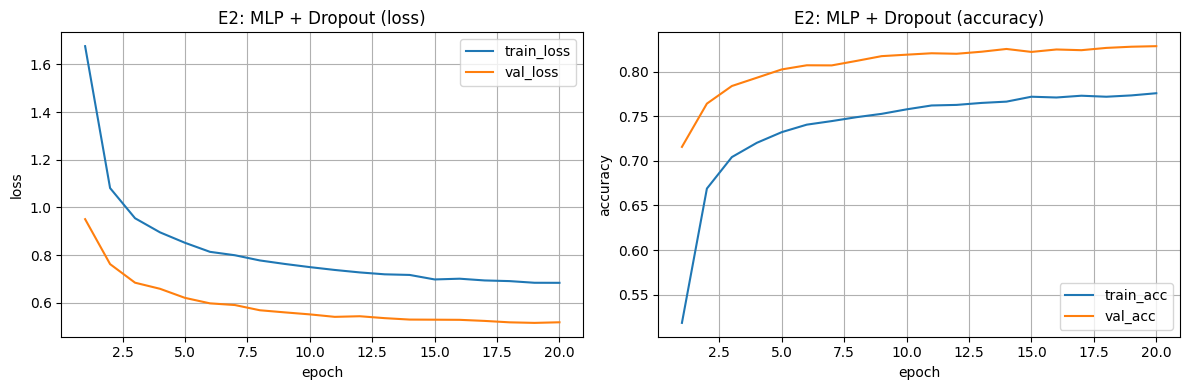

E2 Test: loss=0.5428, acc=0.8198


In [14]:
# Эксперимент E2 (Dropout): как E1, но с Dropout
set_seed(42)
model_e2 = MLP(hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e2.parameters(), lr=1e-3)

history_e2 = fit(
    model_e2, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_e2, title="E2: MLP + Dropout")

# Оценка на тесте
test_loss_e2, test_acc_e2 = evaluate(model_e2, test_loader, criterion, device)
print(f"E2 Test: loss={test_loss_e2:.4f}, acc={test_acc_e2:.4f}")

epoch 01/20 | train loss=0.9953, acc=0.7285 | val loss=0.6001, acc=0.8110
epoch 02/20 | train loss=0.5278, acc=0.8260 | val loss=0.5151, acc=0.8295
epoch 03/20 | train loss=0.4498, acc=0.8465 | val loss=0.4851, acc=0.8403
epoch 04/20 | train loss=0.4026, acc=0.8595 | val loss=0.4720, acc=0.8429
epoch 05/20 | train loss=0.3702, acc=0.8681 | val loss=0.4702, acc=0.8386
epoch 06/20 | train loss=0.3427, acc=0.8758 | val loss=0.4636, acc=0.8466
epoch 07/20 | train loss=0.3235, acc=0.8821 | val loss=0.4643, acc=0.8472
epoch 08/20 | train loss=0.3046, acc=0.8866 | val loss=0.4663, acc=0.8464
epoch 09/20 | train loss=0.2874, acc=0.8913 | val loss=0.4688, acc=0.8479
epoch 10/20 | train loss=0.2729, acc=0.8956 | val loss=0.4729, acc=0.8495
epoch 11/20 | train loss=0.2624, acc=0.8994 | val loss=0.4792, acc=0.8493
epoch 12/20 | train loss=0.2487, acc=0.9037 | val loss=0.4921, acc=0.8445
epoch 13/20 | train loss=0.2382, acc=0.9066 | val loss=0.5033, acc=0.8460
epoch 14/20 | train loss=0.2296, acc=0

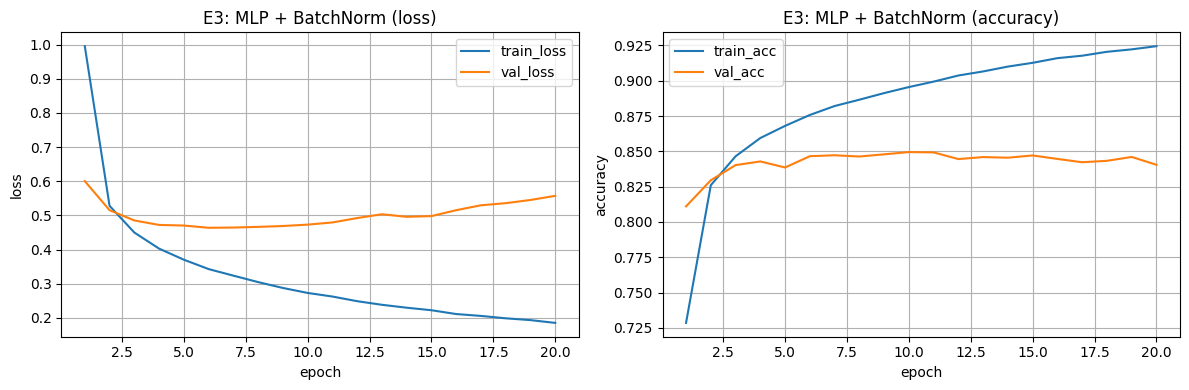

E3 Test: loss=0.5835, acc=0.8361


In [15]:
# Эксперимент E3 (BatchNorm): как E1, но с BatchNorm
set_seed(42)
model_e3 = MLP(hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e3.parameters(), lr=1e-3)

history_e3 = fit(
    model_e3, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=20,
    early_stopping=None
)

plot_history(history_e3, title="E3: MLP + BatchNorm")

# Оценка на тесте
test_loss_e3, test_acc_e3 = evaluate(model_e3, test_loader, criterion, device)
print(f"E3 Test: loss={test_loss_e3:.4f}, acc={test_acc_e3:.4f}")

Выбираем E3 (BatchNorm) как основу для E4
epoch 01/30 | train loss=0.9953, acc=0.7285 | val loss=0.6001, acc=0.8110
epoch 02/30 | train loss=0.5278, acc=0.8260 | val loss=0.5151, acc=0.8295
epoch 03/30 | train loss=0.4498, acc=0.8465 | val loss=0.4851, acc=0.8403
epoch 04/30 | train loss=0.4026, acc=0.8595 | val loss=0.4720, acc=0.8429
epoch 05/30 | train loss=0.3702, acc=0.8681 | val loss=0.4702, acc=0.8386
epoch 06/30 | train loss=0.3427, acc=0.8758 | val loss=0.4636, acc=0.8466
epoch 07/30 | train loss=0.3235, acc=0.8821 | val loss=0.4643, acc=0.8472
epoch 08/30 | train loss=0.3046, acc=0.8866 | val loss=0.4663, acc=0.8464
epoch 09/30 | train loss=0.2874, acc=0.8913 | val loss=0.4688, acc=0.8479
epoch 10/30 | train loss=0.2729, acc=0.8956 | val loss=0.4729, acc=0.8495
epoch 11/30 | train loss=0.2624, acc=0.8994 | val loss=0.4792, acc=0.8493
epoch 12/30 | train loss=0.2487, acc=0.9037 | val loss=0.4921, acc=0.8445
epoch 13/30 | train loss=0.2382, acc=0.9066 | val loss=0.5033, acc=0.8

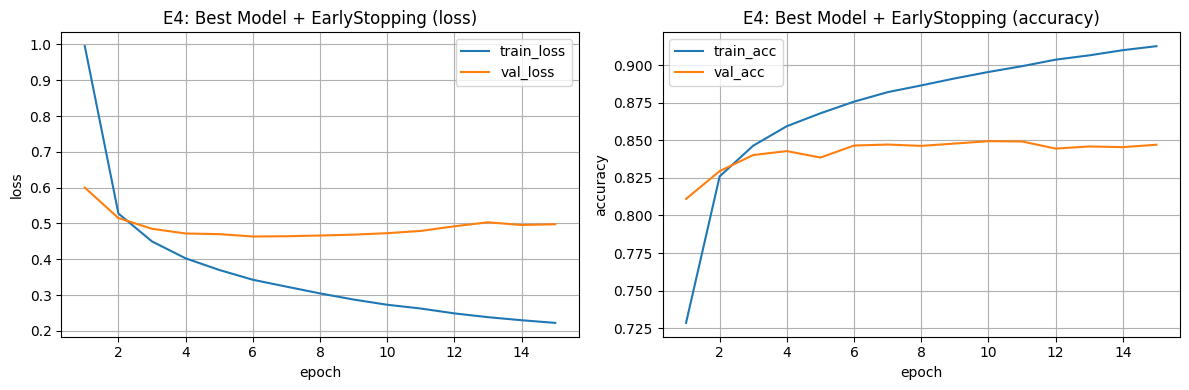

E4 Test: loss=0.4912, acc=0.8439


In [ ]:
# Эксперимент E4 (EarlyStopping): лучший из (E2/E3) с EarlyStopping
# Сравним val_acc E2 и E3, чтобы выбрать лучший для E4
best_val_acc_e2 = max(history_e2["val_acc"])
best_val_acc_e3 = max(history_e3["val_acc"])

if best_val_acc_e2 >= best_val_acc_e3:
    print("Выбираем E2 (Dropout) как основу для E4")
    base_hidden_dims = (256, 128)
    base_dropout_p = 0.3
    base_use_batchnorm = False
    base_model = model_e2
else:
    print("Выбираем E3 (BatchNorm) как основу для E4")
    base_hidden_dims = (256, 128)
    base_dropout_p = 0.0
    base_use_batchnorm = True
    base_model = model_e3

# Создаем модель для E4 с теми же параметрами, что и лучшая модель
set_seed(42)
model_e4 = MLP(hidden_dims=base_hidden_dims, dropout_p=base_dropout_p, use_batchnorm=base_use_batchnorm).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_e4.parameters(), lr=1e-3)

es = EarlyStopping(patience=5, min_delta=0.0005)

history_e4 = fit(
    model_e4, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=30,  
    early_stopping=es,
    verbose=True
)

plot_history(history_e4, title="E4: Best Model + EarlyStopping")

# Оценка на тесте
test_loss_e4, test_acc_e4 = evaluate(model_e4, test_loader, criterion, device)
print(f"E4 Test: loss={test_loss_e4:.4f}, acc={test_acc_e4:.4f}")

# Часть B (S09): LR, оптимизаторы, weight decay

epoch 01/8 | train loss=1.0947, acc=0.6701 | val loss=0.8400, acc=0.7311
epoch 02/8 | train loss=0.7796, acc=0.7515 | val loss=0.7410, acc=0.7665
epoch 03/8 | train loss=0.7028, acc=0.7716 | val loss=0.6882, acc=0.7716
epoch 04/8 | train loss=0.6534, acc=0.7849 | val loss=0.6718, acc=0.7934
epoch 05/8 | train loss=0.6220, acc=0.7952 | val loss=0.6434, acc=0.7925
epoch 06/8 | train loss=0.6040, acc=0.7993 | val loss=0.6129, acc=0.8045
epoch 07/8 | train loss=0.5849, acc=0.8040 | val loss=0.6184, acc=0.8036
epoch 08/8 | train loss=0.5656, acc=0.8095 | val loss=0.6012, acc=0.8128


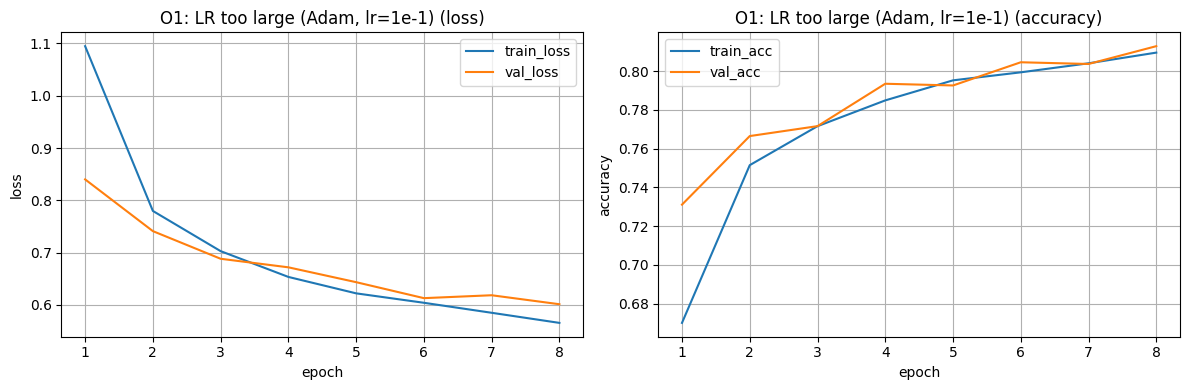

O1 Test: loss=0.6346, acc=0.8056


In [ ]:
# Эксперимент O1 (LR слишком большой): Adam, lr = 1e-1
set_seed(42)
model_o1 = MLP(hidden_dims=base_hidden_dims, dropout_p=base_dropout_p, use_batchnorm=base_use_batchnorm).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_o1.parameters(), lr=1e-1)  

history_o1 = fit(
    model_o1, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,  
    early_stopping=None,
    verbose=True
)

plot_history(history_o1, title="O1: LR too large (Adam, lr=1e-1)")

# Оценка на тесте
test_loss_o1, test_acc_o1 = evaluate(model_o1, test_loader, criterion, device)
print(f"O1 Test: loss={test_loss_o1:.4f}, acc={test_acc_o1:.4f}")

epoch 01/8 | train loss=3.4800, acc=0.1641 | val loss=3.1291, acc=0.3131
epoch 02/8 | train loss=2.9190, acc=0.3991 | val loss=2.7261, acc=0.4683
epoch 03/8 | train loss=2.5943, acc=0.5060 | val loss=2.4562, acc=0.5417
epoch 04/8 | train loss=2.3507, acc=0.5625 | val loss=2.2316, acc=0.5884
epoch 05/8 | train loss=2.1489, acc=0.6002 | val loss=2.0482, acc=0.6168
epoch 06/8 | train loss=1.9754, acc=0.6262 | val loss=1.8913, acc=0.6387
epoch 07/8 | train loss=1.8247, acc=0.6473 | val loss=1.7531, acc=0.6585
epoch 08/8 | train loss=1.6928, acc=0.6641 | val loss=1.6279, acc=0.6735


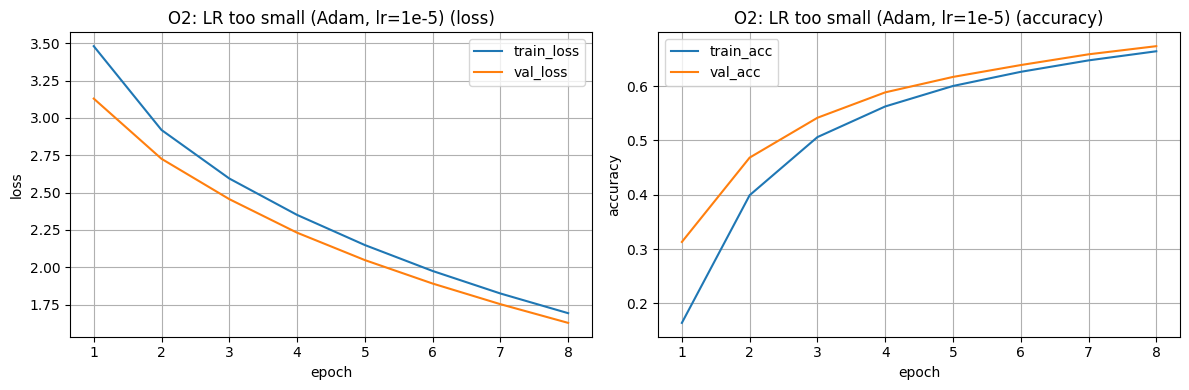

O2 Test: loss=1.6352, acc=0.6675


In [ ]:
# Эксперимент O2 (LR слишком маленький): Adam, lr = 1e-5
set_seed(42)
model_o2 = MLP(hidden_dims=base_hidden_dims, dropout_p=base_dropout_p, use_batchnorm=base_use_batchnorm).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_o2.parameters(), lr=1e-5)  

history_o2 = fit(
    model_o2, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=8,  
    early_stopping=None,
    verbose=True
)

plot_history(history_o2, title="O2: LR too small (Adam, lr=1e-5)")

# Оценка на тесте
test_loss_o2, test_acc_o2 = evaluate(model_o2, test_loader, criterion, device)
print(f"O2 Test: loss={test_loss_o2:.4f}, acc={test_acc_o2:.4f}")

epoch 01/15 | train loss=1.1147, acc=0.6995 | val loss=0.6483, acc=0.7990
epoch 02/15 | train loss=0.5790, acc=0.8139 | val loss=0.5361, acc=0.8289
epoch 03/15 | train loss=0.4866, acc=0.8372 | val loss=0.5122, acc=0.8332
epoch 04/15 | train loss=0.4369, acc=0.8510 | val loss=0.4917, acc=0.8378
epoch 05/15 | train loss=0.4036, acc=0.8599 | val loss=0.4804, acc=0.8366
epoch 06/15 | train loss=0.3774, acc=0.8674 | val loss=0.4708, acc=0.8447
epoch 07/15 | train loss=0.3563, acc=0.8737 | val loss=0.4627, acc=0.8479
epoch 08/15 | train loss=0.3371, acc=0.8785 | val loss=0.4681, acc=0.8457
epoch 09/15 | train loss=0.3202, acc=0.8837 | val loss=0.4586, acc=0.8476
epoch 10/15 | train loss=0.3059, acc=0.8873 | val loss=0.4586, acc=0.8486
epoch 11/15 | train loss=0.2957, acc=0.8908 | val loss=0.4652, acc=0.8475
epoch 12/15 | train loss=0.2843, acc=0.8953 | val loss=0.4664, acc=0.8434
epoch 13/15 | train loss=0.2735, acc=0.8987 | val loss=0.4730, acc=0.8470
epoch 14/15 | train loss=0.2636, acc=0

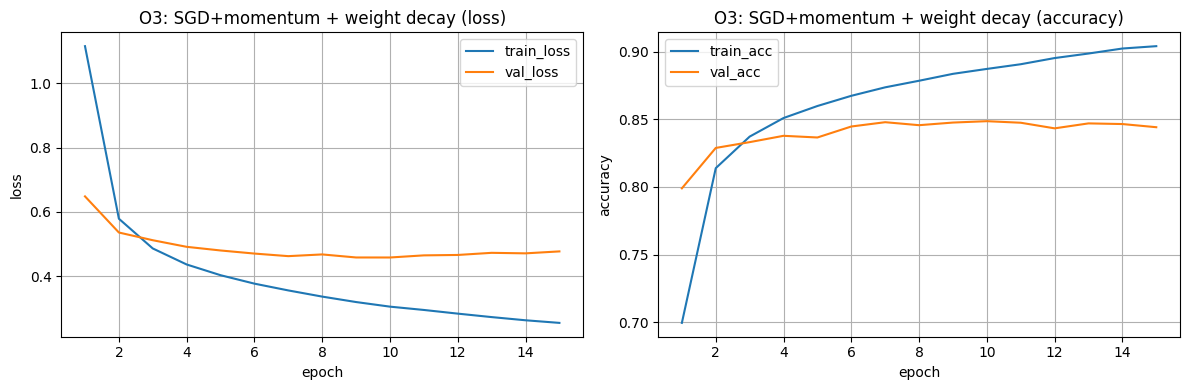

O3 Test: loss=0.4949, acc=0.8379


In [ ]:
# Эксперимент O3 (SGD+momentum + weight decay): SGD с momentum и weight_decay
set_seed(42)
model_o3 = MLP(hidden_dims=base_hidden_dims, dropout_p=base_dropout_p, use_batchnorm=base_use_batchnorm).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)

history_o3 = fit(
    model_o3, train_loader, val_loader,
    optimizer, criterion, device,
    epochs=15,  
    early_stopping=None,
    verbose=True
)

plot_history(history_o3, title="O3: SGD+momentum + weight decay")

# Оценка на тесте
test_loss_o3, test_acc_o3 = evaluate(model_o3, test_loader, criterion, device)
print(f"O3 Test: loss={test_loss_o3:.4f}, acc={test_acc_o3:.4f}")

In [ ]:
# Создание таблицы результатов
results_data = [
    {
        "experiment_id": "E1",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "hidden_sizes: (256, 128), activation: relu, dropout: 0.0, batchnorm: False",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history_e1["train_loss"]),
        "best_val_accuracy": max(history_e1["val_acc"]),
        "best_val_loss": min(history_e1["val_loss"])
    },
    {
        "experiment_id": "E2",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "hidden_sizes: (256, 128), activation: relu, dropout: 0.3, batchnorm: False",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history_e2["train_loss"]),
        "best_val_accuracy": max(history_e2["val_acc"]),
        "best_val_loss": min(history_e2["val_loss"])
    },
    {
        "experiment_id": "E3",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": "hidden_sizes: (256, 128), activation: relu, dropout: 0.0, batchnorm: True",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history_e3["train_loss"]),
        "best_val_accuracy": max(history_e3["val_acc"]),
        "best_val_loss": min(history_e3["val_loss"])
    },
    {
        "experiment_id": "E4",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": f"hidden_sizes: {base_hidden_dims}, activation: relu, dropout: {base_dropout_p}, batchnorm: {base_use_batchnorm}",
        "optimizer": "Adam",
        "lr": 1e-3,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history_e4["train_loss"]),
        "best_val_accuracy": max(history_e4["val_acc"]),
        "best_val_loss": min(history_e4["val_loss"])
    },
    {
        "experiment_id": "O1",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": f"hidden_sizes: {base_hidden_dims}, activation: relu, dropout: {base_dropout_p}, batchnorm: {base_use_batchnorm}",
        "optimizer": "Adam",
        "lr": 1e-1,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history_o1["train_loss"]),
        "best_val_accuracy": max(history_o1["val_acc"]),
        "best_val_loss": min(history_o1["val_loss"])
    },
    {
        "experiment_id": "O2",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": f"hidden_sizes: {base_hidden_dims}, activation: relu, dropout: {base_dropout_p}, batchnorm: {base_use_batchnorm}",
        "optimizer": "Adam",
        "lr": 1e-5,
        "momentum": 0.0,
        "weight_decay": 0.0,
        "epochs_trained": len(history_o2["train_loss"]),
        "best_val_accuracy": max(history_o2["val_acc"]),
        "best_val_loss": min(history_o2["val_loss"])
    },
    {
        "experiment_id": "O3",
        "dataset": "EMNIST",
        "seed": 42,
        "model_summary": f"hidden_sizes: {base_hidden_dims}, activation: relu, dropout: {base_dropout_p}, batchnorm: {base_use_batchnorm}",
        "optimizer": "SGD",
        "lr": 1e-2,
        "momentum": 0.9,
        "weight_decay": 1e-4,
        "epochs_trained": len(history_o3["train_loss"]),
        "best_val_accuracy": max(history_o3["val_acc"]),
        "best_val_loss": min(history_o3["val_loss"])
    }
]

df_results = pd.DataFrame(results_data)
print(df_results[["experiment_id", "best_val_accuracy", "best_val_loss", "epochs_trained"]])

import os
from pathlib import Path

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True) 

output_path = artifacts_dir / "runs.csv"
df_results.to_csv(output_path, index=False)
print(f"Файл сохранен: {output_path}")

  experiment_id  best_val_accuracy  best_val_loss  epochs_trained
0            E1           0.839689       0.510492              20
1            E2           0.828390       0.515125              20
2            E3           0.849488       0.463584              20
3            E4           0.849488       0.463584              15
4            O1           0.812809       0.601228               8
5            O2           0.673464       1.627919               8
6            O3           0.848649       0.458554              15
Файл сохранен: artifacts\runs.csv


In [ ]:

# 2. Сохранение лучшей модели (E4)
model_path = artifacts_dir / "best_model.pt"
torch.save(model_e4.state_dict(), model_path)
print(f"Модель сохранена: {model_path}")

# 3. Сохранение конфигурации лучшей модели
best_config = {
    "model_architecture": {
        "input_dim": 28 * 28,
        "hidden_dims": base_hidden_dims,
        "num_classes": 47,
        "activation": "relu",
        "dropout_p": base_dropout_p,
        "use_batchnorm": base_use_batchnorm
    },
    "training_params": {
        "optimizer": "Adam",
        "lr": 1e-3,
        "criterion": "CrossEntropyLoss",
        "batch_size": BATCH_SIZE,
        "early_stopping": {
            "patience": 5,
            "min_delta": 0.0005
        }
    },
    "dataset": "EMNIST_balanced",
    "seed": 42
}

config_path = artifacts_dir / "best_config.json"
with open(config_path, "w") as f:
    json.dump(best_config, f, indent=2)
print(f"Конфигурация сохранена: {config_path}")

Модель сохранена: artifacts\best_model.pt
Конфигурация сохранена: artifacts\best_config.json


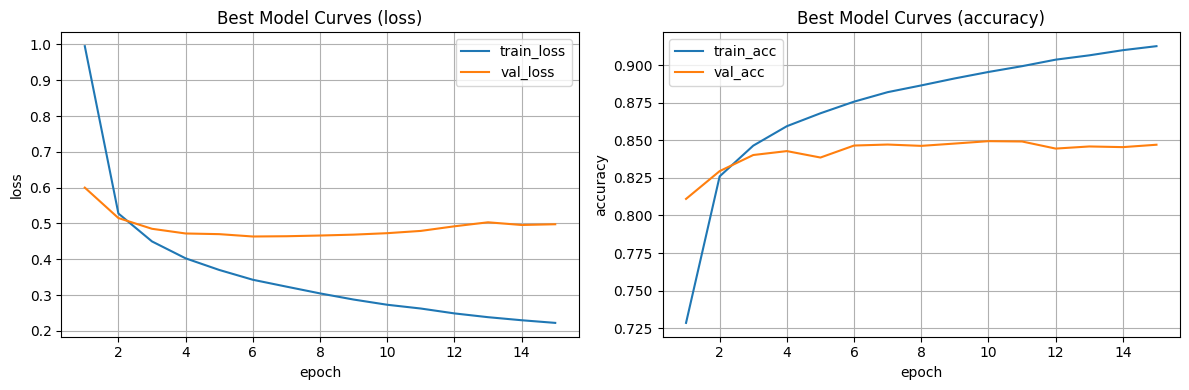

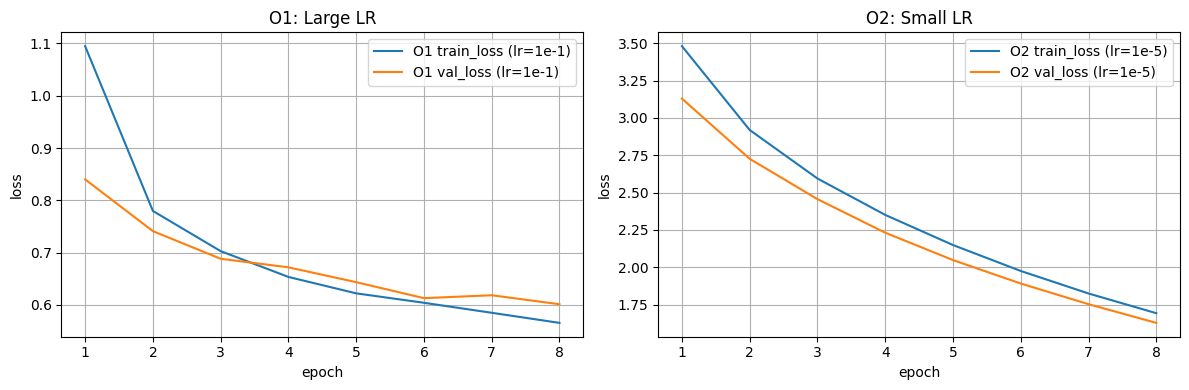

Графики сохранены в: artifacts\figures


In [25]:

figures_dir = Path("artifacts/figures")

# Сохранение графиков
plot_history(history_e4, title="Best Model Curves")
plt.savefig(figures_dir / "curves_best.png", dpi=300, bbox_inches='tight')
plt.close()

# График для O1 и O2 (LR слишком большой/маленький)
epochs_o1 = np.arange(1, len(history_o1["train_loss"]) + 1)
epochs_o2 = np.arange(1, len(history_o2["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_o1, history_o1["train_loss"], label="O1 train_loss (lr=1e-1)")
plt.plot(epochs_o1, history_o1["val_loss"], label="O1 val_loss (lr=1e-1)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("O1: Large LR")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_o2, history_o2["train_loss"], label="O2 train_loss (lr=1e-5)")
plt.plot(epochs_o2, history_o2["val_loss"], label="O2 val_loss (lr=1e-5)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("O2: Small LR")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(figures_dir / "curves_lr_extremes.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Графики сохранены в: {figures_dir}")

In [26]:
# Финальная оценка лучшей модели (E4) на тесте
final_test_loss, final_test_acc = evaluate(model_e4, test_loader, criterion, device)
print(f"Финальная оценка лучшей модели (E4) на тесте: loss={final_test_loss:.4f}, acc={final_test_acc:.4f}")

Финальная оценка лучшей модели (E4) на тесте: loss=0.4912, acc=0.8439
